In [1]:
import pandas as pd, numpy as np, torch

In [2]:
df=pd.read_csv('/content/Tit_train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum()##to check null  values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
## treating missing value
modes=df.mode().iloc[0] ## works with both categorical and continuous

In [6]:
df.fillna(modes,inplace=True)

In [7]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df.describe(include=(np.number))

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

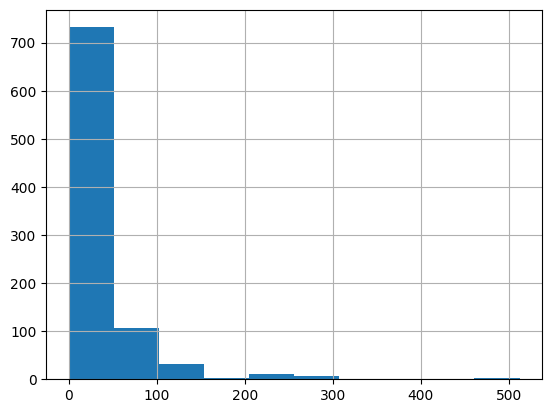

In [9]:
df.Fare.hist() ## here as we can se long tailed which doesnt go well with like linearmodel,  so we will transform it

In [10]:
df['LogFare']=np.log(df['Fare']+1)

<Axes: >

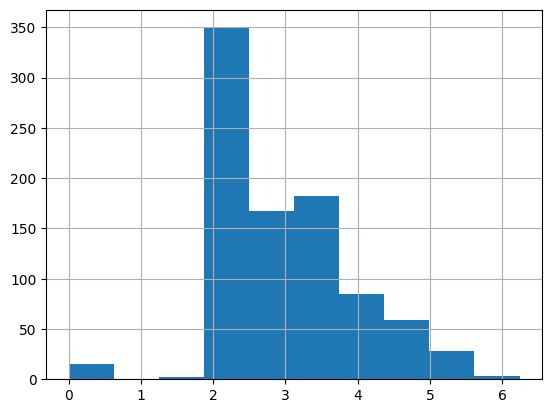

In [11]:
df['LogFare'].hist()

In [12]:
pclasses=sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

In [13]:
##describe non nuumeric variable
df.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,1601,B96 B98,S
freq,1,577,7,691,646


In [14]:
df=pd.get_dummies(df,columns=['Sex','Pclass',"Embarked"]) ## to get dummies variable of categories columns
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [15]:
added_cols=['Sex_female','Sex_male', 'Pclass_1','Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
df[added_cols].head().astype(int)

,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1,0,0,1
1,1,0,1,0,0,1,0,0
2,1,0,0,0,1,0,0,1
3,1,0,1,0,0,0,0,1
4,0,1,0,0,1,0,0,1


In [16]:
from torch import tensor

In [17]:
## Creating tensor of dependent variable
t_dep=tensor(df.Survived)
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [18]:
indep_cols=['Age','SibSp','Parch','LogFare'] +added_cols
indep_cols

['Age',
 'SibSp',
 'Parch',
 'LogFare',
 'Sex_female',
 'Sex_male',
 'Pclass_1',
 'Pclass_2',
 'Pclass_3',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S']

In [19]:
t_indep=tensor(df[indep_cols].values.astype(np.float32),dtype=torch.float)# pytorch wants dataype tpbe float if  you want to multiply things toggether


In [20]:
t_indep.shape

torch.Size([891, 12])

In [21]:
len(t_indep.shape)# len of this  gives us rank of tenso r with 0 randk for scalar ,then 1 for vetcor and rank 2  for table

2

In [22]:
##Setting up a linear model
torch.manual_seed(442)
#We  wil satrt  with random coeffecient as discussed in exxcel
n_coeffs=t_indep.shape[1]  # will give numbe no of columns required
coeffs=torch.rand(n_coeffs)-0.5 # creation of random coeffs
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,
         0.2799, -0.4392,  0.2103,  0.3625])

In [23]:
t_indep*coeffs ##  Matrix  multiplication with vector using broadcasting and is a very optimized way

tensor([[-10.1838,   0.1386,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.1096,   0.1386,   0.4818,  ...,  -0.0000,   0.0000,   0.3625],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-14.8128,   0.0000,   0.0000,  ...,  -0.0000,   0.2103,   0.0000]])

In [24]:
##Age column is  bigger  than other column so we may need to transform or normalize it
vals,indices=t_indep.max(dim=0)
t_indep=t_indep/vals
t_indep


tensor([[0.2750, 0.1250, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
        ...,
        [0.3000, 0.1250, 0.3333,  ..., 0.0000, 0.0000, 1.0000],
        [0.3250, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.4000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.0000]])

In [25]:
t_indep*coeffs

tensor([[-0.1273,  0.0173,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1389,  0.0173,  0.0803,  ..., -0.0000,  0.0000,  0.3625],
        [-0.1504,  0.0000,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1852,  0.0000,  0.0000,  ..., -0.0000,  0.2103,  0.0000]])

In [26]:
# now as we need to find product sum of each row to  get the prediction as in excel
preds=(t_indep*coeffs).sum(axis=1)
preds[:10]

tensor([ 0.1412, -0.5725,  0.1494,  0.2571,  0.0453, -0.0448,  0.0792,  0.2961,
         0.2128, -0.5770])

In [27]:
##now we will use gradient descent to make them better  for which we need loss .
loss=torch.abs(preds-t_dep).mean() ##Mean absolute value
loss

tensor(0.5200)

In [28]:
## we can turnn to function
def calc_preds(coeffs,indeps):
  return (indeps*coeffs).sum(axis=1)

def calc_loss(coeffs,indeps,deps):
  return torch.abs(calc_preds(coeffs,indeps)-deps).mean()

In [29]:
## Doing a gradient descent step
##gradient descent involves caclau=ating deriavtives which can be easily done wit the help  of torch require_grad
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,
         0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

In [30]:
loss=calc_loss(coeffs,t_indep,t_dep)
loss ## now ehre grad_function is stored which instructs python to do gradinet

tensor(0.5200, grad_fn=<MeanBackward0>)

In [31]:
loss.backward()

In [32]:
coeffs.grad## gives how to decrease loss by changinging coeffs value.example  age need to be decreased

tensor([-0.0483,  0.0118, -0.0041, -0.0804, -0.1975,  0.1111, -0.1235, -0.0426,
         0.0797, -0.1886, -0.0617,  0.1639])

In [33]:
with torch.no_grad():
  coeffs.sub_(coeffs.grad*0.1) #here 0.1  is the learning rate
  print(calc_loss(coeffs,t_indep,t_dep))## output loss will be reduced each

tensor(0.5056)


In [34]:
!pip install  fastai

In [35]:
## tarining the linear model
from fastai.data.transforms import RandomSplitter
trn_split,val_split=RandomSplitter(seed=42)(df) ##gives list of  rows index that will be in trn and val set


In [36]:
trn_indep,val_indep=t_indep[trn_split],t_indep[val_split]
trn_dep,val_dep=t_dep[trn_split],t_dep[val_split]
len(trn_indep),len(val_indep)

(713, 178)

In [37]:
def update_coeffs(coeffs,lr):
  coeffs.sub_(coeffs.grad*0.1)

In [38]:
def one_epoch(coeffs,lr):
  loss=calc_loss(coeffs,trn_indep,trn_dep)
  loss.backward()
  with torch.no_grad():
    update_coeffs(coeffs,lr)
    print(f"{loss:.3f}",end="; ")

In [39]:
def init_coeffs():
  return (torch.rand(n_coeffs)-0.5).requires_grad_()

In [40]:
def train_model(epochs=30,lr=0.01):
  torch.manual_seed(442)
  coeffs=init_coeffs()
  for i  in range(epochs):
    one_epoch(coeffs,lr=lr)
  return coeffs

In [41]:
coeffs=train_model(epochs=8,lr=0.02)

0.518; 0.504; 0.480; 0.449; 0.399; 0.351; 0.307; 0.293; 

In [42]:
def show_coeffs():
  return dict(zip(indep_cols,coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2105),
 'SibSp': tensor(0.0986),
 'Parch': tensor(0.2526),
 'LogFare': tensor(0.1186),
 'Sex_female': tensor(0.3665),
 'Sex_male': tensor(-0.4306),
 'Pclass_1': tensor(0.8730),
 'Pclass_2': tensor(0.4336),
 'Pclass_3': tensor(0.2883),
 'Embarked_C': tensor(0.2074),
 'Embarked_Q': tensor(0.3312),
 'Embarked_S': tensor(0.1089)}

In [43]:
###  lets move to metric  of the compettition
## Accuarcy

In [44]:
preds=calc_preds(coeffs,val_indep)
preds.shape

torch.Size([178])

In [45]:
results=val_dep.bool()==(preds>0.5)
results[:16].float()


tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0.])

In [46]:
results.float().mean()

tensor(0.7921)

In [47]:
def acc(coeffs):
  return (val_dep.bool()==(calc_preds(coeffs,val_indep)>0.5)).float().mean()

In [48]:
acc(coeffs)

tensor(0.7921)

In [49]:
##using sigmoid

In [50]:
preds[:28] ## pred are sometime less than 1 and more than 1 but value  should be b/w  0 and 1 as survive dr  not survived
#So we will introduce sigmoid actiavtion fucnnttion at final layer

tensor([ 1.1174,  0.1670,  0.0420,  0.1466,  0.0964,  0.0936,  0.9445,  0.8855,
         0.1834,  0.9133, -0.0759,  0.1094,  0.0580,  0.9643, -0.0845,  0.4960,
         0.4434,  0.9480,  0.0720,  0.7253, -0.0550,  0.4670,  1.4884,  0.9589,
        -0.0463,  0.1994,  0.8629,  0.4513])

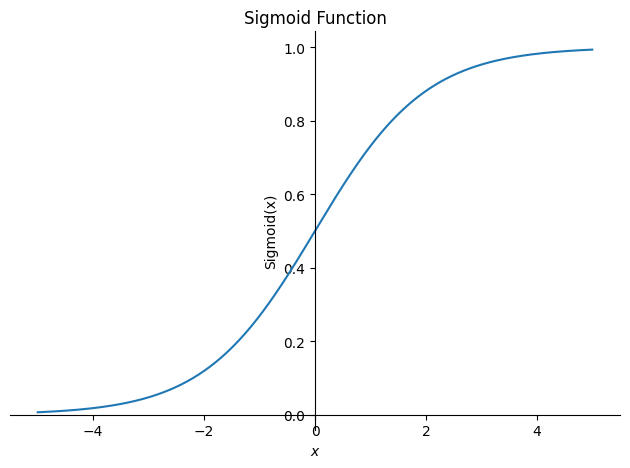

In [51]:
import sympy as sp ##symbolic python
from sympy.plotting import plot

# Define the variable
x = sp.symbols('x')

# Define the expression (this is the sigmoid function)
expr = 1 / (1 + sp.exp(-x))

# Plot the expression
plot(expr, (x, -5, 5), ylabel='Sigmoid(x)', title='Sigmoid Function')


In [52]:
def calc_preds(coeffs,indeps):
  return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [53]:
coeffs=train_model(epochs=60,lr=2)

0.503; 0.501; 0.497; 0.490; 0.482; 0.471; 0.459; 0.445; 0.430; 0.415; 0.399; 0.384; 0.370; 0.358; 0.346; 0.336; 0.328; 0.321; 0.314; 0.309; 0.303; 0.298; 0.294; 0.289; 0.285; 0.280; 0.275; 0.271; 0.266; 0.262; 0.257; 0.253; 0.248; 0.244; 0.240; 0.236; 0.233; 0.229; 0.226; 0.223; 0.221; 0.219; 0.217; 0.215; 0.213; 0.212; 0.210; 0.209; 0.208; 0.208; 0.207; 0.206; 0.206; 0.205; 0.205; 0.205; 0.205; 0.204; 0.204; 0.204; 

In [54]:
coeffs

tensor([-1.1166, -0.1339,  0.3366,  0.4570,  6.0012, -7.7805,  3.0268,  1.3369,
        -4.4840,  0.7874,  0.2176, -2.0728], requires_grad=True)

In [55]:
acc(coeffs)

tensor(0.8258)

In [56]:
show_coeffs()

{'Age': tensor(-1.1166),
 'SibSp': tensor(-0.1339),
 'Parch': tensor(0.3366),
 'LogFare': tensor(0.4570),
 'Sex_female': tensor(6.0012),
 'Sex_male': tensor(-7.7805),
 'Pclass_1': tensor(3.0268),
 'Pclass_2': tensor(1.3369),
 'Pclass_3': tensor(-4.4840),
 'Embarked_C': tensor(0.7874),
 'Embarked_Q': tensor(0.2176),
 'Embarked_S': tensor(-2.0728)}

In [57]:
tst_df=pd.read_csv('/content/Tit_test.csv')


In [58]:
tst_df['Fare']=tst_df.Fare.fillna(0)

In [59]:
tst_df.fillna(modes,inplace=True)
tst_df['LogFare']=np.log(tst_df['Fare']+1)
tst_df=pd.get_dummies(tst_df,columns=['Sex','Pclass',"Embarked"])


In [60]:
tst_indep=tensor(tst_df[indep_cols].values.astype(np.float32),dtype=torch.float)
tst_indep=tst_indep/vals

In [61]:
tst_df['Survived']=(calc_preds(coeffs,tst_indep)>0.5).int() ##int convert into  0 and 1



In [62]:
sub_df=tst_df[['PassengerId','Survived']]

In [63]:
sub_df.shape

(418, 2)

In [64]:
sub_df.to_csv('submission.csv',index=False) ##File for submitting to kaggle

## ## using matrix product

In [65]:
(val_indep * coeffs).sum(axis=1)
## SO  val_indep * coeffs we are not atking as it is element wise operation,howeever we are doing matrix multiplication but will  have same value

tensor([  7.4105, -12.2232, -11.6578,  -8.4520,  -8.6721,  -8.7814,   2.5002,
          5.0677, -14.0394,   2.2397, -14.6237, -11.5686, -14.1710,   1.5597,
        -14.6644,  -7.2119,  -7.4910,   5.2138,  -8.8194,  -0.8221, -14.5123,
         -7.3654,   9.6558,   4.9976, -14.4637, -12.1625,  -0.3474,  -7.4492,
        -14.4085,   1.5586,   5.3195,  -0.4671, -14.4425, -14.6017,   7.3267,
         -0.2838,  -7.2222,   9.7917, -14.5110,  -0.7610,  -8.6028, -14.5110,
         -8.6723,   9.6870, -14.4552,  -0.5760, -14.4035, -14.3785, -12.2301,
         -0.7082,  -4.8535, -14.1511, -14.1630, -14.5335,  -8.7005,  -8.7842,
        -12.2231, -14.6510, -14.4691, -14.5272,  -4.1392, -14.4386,  -7.6918,
        -14.4702,   4.8757,  -6.7443,  -8.6582, -14.6455, -12.3606,   4.8330,
        -14.5402,   2.2859,  -8.7703, -14.5001,  -6.9204, -14.4016, -14.5110,
         -7.0434,  -8.5884,  -8.9694,  -8.2376,  10.0091, -14.4983, -14.5178,
          4.7462,  -5.6350,  -3.8902,   7.2064,   7.9536,  -8.64

In [66]:
val_indep @ coeffs ##mattrix multiplication

tensor([  7.4105, -12.2232, -11.6578,  -8.4520,  -8.6721,  -8.7814,   2.5002,
          5.0677, -14.0394,   2.2397, -14.6237, -11.5686, -14.1710,   1.5597,
        -14.6644,  -7.2119,  -7.4910,   5.2138,  -8.8194,  -0.8221, -14.5123,
         -7.3654,   9.6558,   4.9976, -14.4637, -12.1625,  -0.3474,  -7.4492,
        -14.4085,   1.5586,   5.3195,  -0.4671, -14.4425, -14.6017,   7.3267,
         -0.2838,  -7.2222,   9.7917, -14.5110,  -0.7610,  -8.6028, -14.5110,
         -8.6723,   9.6870, -14.4552,  -0.5760, -14.4035, -14.3785, -12.2301,
         -0.7082,  -4.8535, -14.1511, -14.1630, -14.5335,  -8.7005,  -8.7842,
        -12.2231, -14.6510, -14.4691, -14.5272,  -4.1392, -14.4386,  -7.6918,
        -14.4702,   4.8757,  -6.7443,  -8.6582, -14.6455, -12.3606,   4.8330,
        -14.5402,   2.2859,  -8.7703, -14.5001,  -6.9204, -14.4016, -14.5110,
         -7.0434,  -8.5884,  -8.9694,  -8.2376,  10.0091, -14.4983, -14.5178,
          4.7462,  -5.6350,  -3.8902,   7.2064,   7.9536,  -8.64

In [67]:
def calc_preds(coeffs,indeps):
  return (indeps @ coeffs)

In [68]:
def init_coeffs():
  return(torch.rand(n_coeffs,1)*0.1).requires_grad_()

In [69]:
trn_dep=trn_dep[:,None]
val_dep=val_dep[:,None]

In [70]:
coeffs=train_model(epochs=100,lr=2)

0.425; 0.391; 0.385; 0.393; 0.337; 0.347; 0.351; 0.353; 0.327; 0.332; 0.402; 0.448; 0.433; 0.360; 0.315; 0.342; 0.322; 0.322; 0.348; 0.362; 0.358; 0.379; 0.371; 0.346; 0.382; 0.384; 0.346; 0.341; 0.389; 0.404; 0.366; 0.354; 0.369; 0.370; 0.349; 0.312; 0.318; 0.372; 0.400; 0.400; 0.389; 0.382; 0.397; 0.389; 0.318; 0.289; 0.326; 0.339; 0.348; 0.387; 0.412; 0.410; 0.381; 0.347; 0.354; 0.378; 0.393; 0.385; 0.359; 0.350; 0.403; 0.404; 0.351; 0.353; 0.403; 0.432; 0.412; 0.353; 0.365; 0.405; 0.397; 0.328; 0.298; 0.360; 0.386; 0.376; 0.367; 0.382; 0.437; 0.428; 0.370; 0.362; 0.379; 0.376; 0.347; 0.303; 0.344; 0.399; 0.439; 0.437; 0.407; 0.381; 0.426; 0.456; 0.413; 0.321; 0.346; 0.430; 0.454; 0.370; 

In [71]:
acc(coeffs)

tensor(0.7697)

In [72]:
coeffs

tensor([[-0.1119],
        [-0.4805],
        [ 0.1643],
        [ 0.4171],
        [ 0.2753],
        [-0.1630],
        [-0.0207],
        [ 0.1672],
        [ 0.1818],
        [ 0.0367],
        [ 0.1016],
        [ 0.0952]], requires_grad=True)

##A neural network


In [73]:
def init_coeffs(n_hidden=20):
  layer1=(torch.rand(n_coeffs,n_hidden)-0.5)/n_hidden
  layer2=torch.rand(n_hidden,1)-0.3
  const=torch.rand(1)[0]
  return layer1.requires_grad_(),layer2.requires_grad_(),const.requires_grad_()

In [74]:
import torch.nn.functional as F
def calc_preds(coeffs,indeps):
  l1,l2,const=coeffs
  res=F.relu(indeps@l1)
  res=res@l2+const
  return torch.sigmoid(res)

In [75]:
def update_coeffs(coeffs,lr):
  for layer in coeffs:
    layer.sub_(layer.grad*lr)

In [76]:
coeffs=train_model(epochs=100,lr=.1)

0.544; 0.542; 0.540; 0.538; 0.535; 0.531; 0.526; 0.520; 0.512; 0.503; 0.492; 0.479; 0.464; 0.447; 0.428; 0.406; 0.382; 0.356; 0.331; 0.308; 0.287; 0.271; 0.259; 0.249; 0.241; 0.235; 0.229; 0.224; 0.219; 0.215; 0.211; 0.208; 0.206; 0.204; 0.203; 0.202; 0.201; 0.200; 0.199; 0.199; 0.198; 0.197; 0.197; 0.196; 0.195; 0.195; 0.194; 0.194; 0.193; 0.193; 0.193; 0.193; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 

In [77]:
acc(coeffs)

tensor(0.8258)

In [78]:
##Deep learning

In [79]:
def init_coeffs():
  hiddens=[10,10]
  sizes=[n_coeffs]+hiddens+[1]
  n=len(sizes)
  layers=[(torch.rand(sizes[i],sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]
  consts=[(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
  for  l in layers+consts:
    l.requires_grad_()
  return layers,consts

In [80]:
def calc_preds(coeffs,indeps):
  layers,consts=coeffs
  n=len(layers)
  res=indeps
  for i,l in enumerate(layers):
    res=  res@l +consts[i]
    if i!=n-1: res = F.relu(res)
  return torch.sigmoid(res)


In [81]:
def update_coeffs(coeffs,lr):
  layers,consts=coeffs
  for layer in layers+consts:
    layer.sub_(layer.grad*lr)

In [82]:
coeffs=train_model(epochs=100,lr=.1)

0.514; 0.502; 0.479; 0.454; 0.438; 0.428; 0.408; 0.379; 0.351; 0.329; 0.310; 0.291; 0.263; 0.230; 0.211; 0.210; 0.214; 0.218; 0.220; 0.221; 0.222; 0.222; 0.222; 0.221; 0.220; 0.218; 0.217; 0.216; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 

In [83]:
acc(coeffs)

tensor(0.7921)